<a href="https://colab.research.google.com/github/guthasushmasree/ML-LabPrograms/blob/main/ml8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload your placement prediction CSV file:


Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv

Uploaded file: placement_predict_50k Dataset.csv

Dataset loaded successfully!
Dataset shape: (50000, 32)

First 5 rows:


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99



Dataset columns:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']

Removed ID columns: ['StudentID']

Categorical columns:
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA_Tier']

Final feature shape: (50000, 46)

Target values before conversion:
PlacementStatus
1    32856
0    17144
Name: count, dtype: int64

Target values after conversion:
PlacementStatus
1    32856
0    17144
Name: count, dtype: int64

Dataset split:
Training   : 35000
Validation : 7500
Testing    : 7500

Training XGBoost...
XGBoost training comp

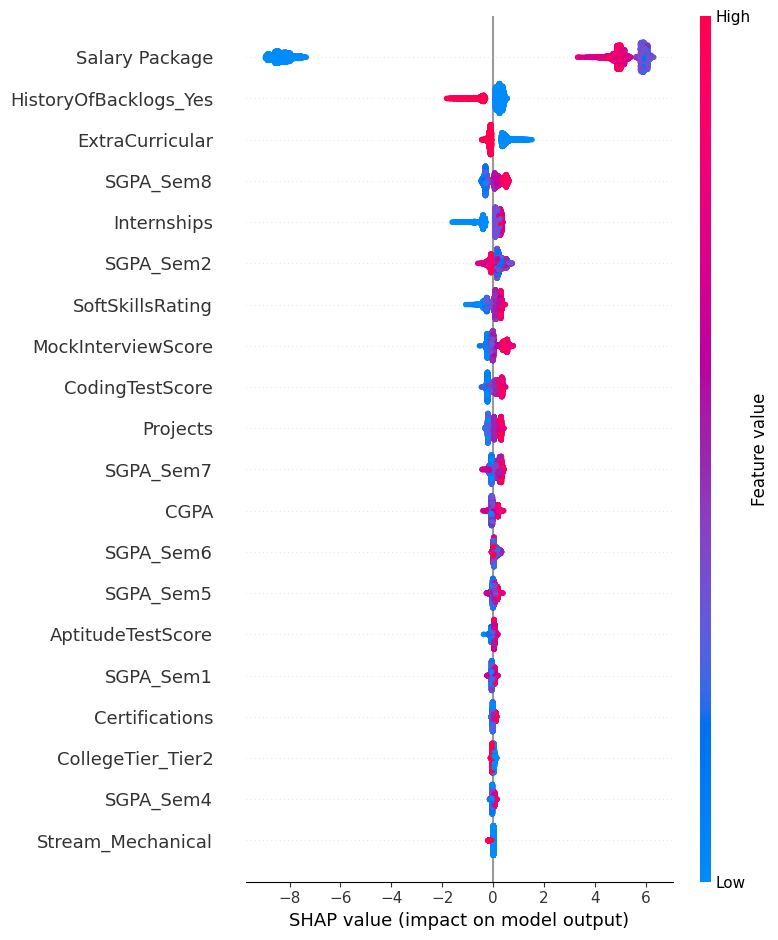


SHAP Waterfall Plot for First Test Student:


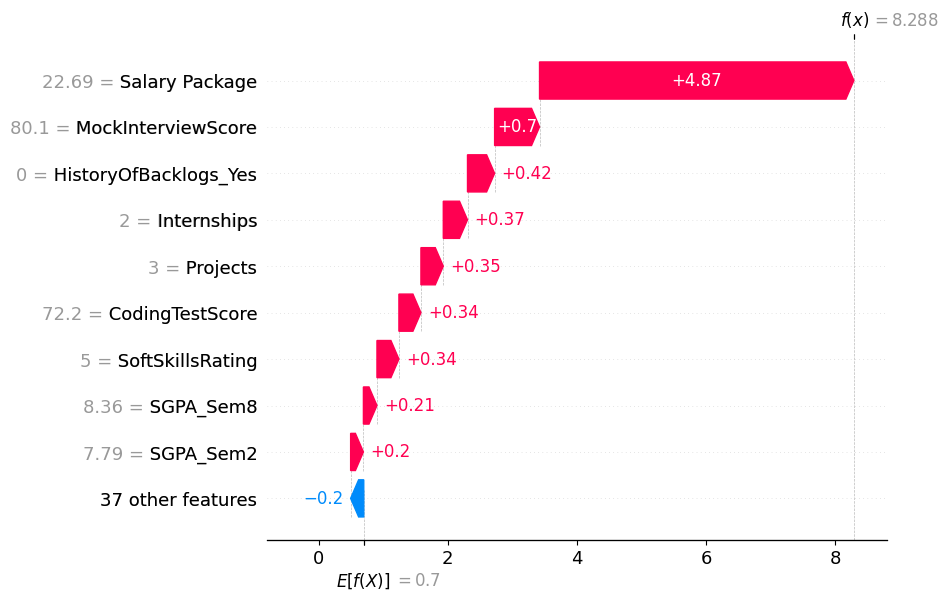


XGBoost model saved as:
placement_model.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Experiment 8 completed successfully!


In [ ]:

import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
import shap
import joblib
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report
)



print("Upload your placement prediction CSV file:")

uploaded = files.upload()

# Automatically detect uploaded filename
filename = list(uploaded.keys())[0]

print("\nUploaded file:", filename)


df = pd.read_csv(filename)

print("\nDataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())


print("\nDataset columns:")
print(df.columns.tolist())



target = "PlacementStatus"

if target not in df.columns:
    raise ValueError(
        f"Target column '{target}' was not found in the dataset."
    )



X = df.drop(columns=[target]).copy()
y = df[target].copy()



id_columns = []

for col in X.columns:

    if col.lower() in [
        "studentid",
        "student_id",
        "id"
    ]:

        id_columns.append(col)


if len(id_columns) > 0:

    X = X.drop(columns=id_columns)

    print("\nRemoved ID columns:", id_columns)



salary_columns = []

for col in X.columns:

    if col.lower() in [
        "salarypackage",
        "salary_package",
        "salary",
        "package"
    ]:

        salary_columns.append(col)


if len(salary_columns) > 0:

    X = X.drop(columns=salary_columns)

    print("Removed leakage columns:", salary_columns)




categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


print("\nCategorical columns:")

print(categorical_columns)


if len(categorical_columns) > 0:

    X = pd.get_dummies(
        X,
        columns=categorical_columns,
        drop_first=True
    )



X = X.apply(
    pd.to_numeric,
    errors="coerce"
)


X = X.fillna(X.median())


X = X.astype(float)


print("\nFinal feature shape:", X.shape)


print("\nTarget values before conversion:")
print(y.value_counts())


if y.dtype == "object":



    unique_values = y.dropna().unique()

    if set(unique_values).issubset(
        {"Yes", "No"}
    ):

        y = y.map({
            "No": 0,
            "Yes": 1
        })

    elif set(unique_values).issubset(
        {"Placed", "Not Placed"}
    ):

        y = y.map({
            "Not Placed": 0,
            "Placed": 1
        })

    else:


        values = list(unique_values)

        if len(values) == 2:

            y = y.map({
                values[0]: 0,
                values[1]: 1
            })

        else:

            raise ValueError(
                "PlacementStatus must contain two classes."
            )


y = y.astype(int)


print("\nTarget values after conversion:")
print(y.value_counts())




Xtr, Xtmp, ytr, ytmp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


Xva, Xte, yva, yte = train_test_split(
    Xtmp,
    ytmp,
    test_size=0.50,
    random_state=42,
    stratify=ytmp
)


print("\nDataset split:")
print("Training   :", Xtr.shape[0])
print("Validation :", Xva.shape[0])
print("Testing    :", Xte.shape[0])



print("\nTraining XGBoost...")

xg = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)


xg.fit(
    Xtr,
    ytr,
    eval_set=[(Xva, yva)],
    verbose=False
)


print("XGBoost training completed!")



print("\nTraining LightGBM...")

lg = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=15,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)


lg.fit(
    Xtr,
    ytr,
    eval_set=[(Xva, yva)],
    callbacks=[
        lgb.early_stopping(
            50,
            verbose=False
        )
    ]
)


print("LightGBM training completed!")



print("\n================================================")
print("MODEL PERFORMANCE")
print("================================================")


for name, model in [
    ("XGBoost", xg),
    ("LightGBM", lg)
]:


    p = model.predict_proba(Xte)[:, 1]

    auc = roc_auc_score(
        yte,
        p
    )

    pr_auc = average_precision_score(
        yte,
        p
    )

    print(
        f"{name:<10} "
        f"AUC={auc:.4f}   "
        f"PR-AUC={pr_auc:.4f}"
    )



print("\n================================================")
print("XGBOOST CLASSIFICATION REPORT")
print("================================================")

xg_predictions = xg.predict(Xte)

print(
    classification_report(
        yte,
        xg_predictions
    )
)



print("\n================================================")
print("LIGHTGBM CLASSIFICATION REPORT")
print("================================================")

lg_predictions = lg.predict(Xte)

print(
    classification_report(
        yte,
        lg_predictions
    )
)


print("\nGenerating SHAP explanations...")



explainer = shap.TreeExplainer(xg)


sv = explainer(Xte)




print("\nSHAP Summary Plot:")

shap.summary_plot(
    sv,
    Xte
)



print("\nSHAP Waterfall Plot for First Test Student:")

shap.plots.waterfall(
    sv[0]
)



joblib.dump(
    xg,
    "placement_model.joblib"
)


print("\n================================================")
print("XGBoost model saved as:")
print("placement_model.joblib")
print("================================================")




files.download(
    "placement_model.joblib"
)


print("\nExperiment 8 completed successfully!")